# GNN 기반 사기 리뷰 탐지 — [2] 버스트 패턴 분석

## 데이터 로드 및 세팅

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from common_utils import load_data, get_burst_months, setup_plotting

setup_plotting()

df = load_data("yelpzip_sampled.csv")

# 시간 기준 분리 (Option B: 사기 비율 균형 cutoff 탐색)
# burst_features.csv 가 05_Model_Training 에서 user 노드 피처로 사용됨
# → train 행만 기준으로 버스트 통계를 계산해야 누수가 없음
df = df.sort_values('date').reset_index(drop=True)
N = len(df)
labels_arr = df['label'].values

best_idx, best_diff = None, float('inf')
for cutoff in range(int(N * 0.72), int(N * 0.88)):
    tr_ratio = labels_arr[:cutoff].mean()
    te_ratio = labels_arr[cutoff:].mean()
    diff = abs(tr_ratio - te_ratio)
    if diff < best_diff:
        best_diff, best_idx = diff, cutoff

idx_trainval = np.arange(best_idx)
idx_test     = np.arange(best_idx, N)
idx_train, _ = train_test_split(
    idx_trainval, test_size=0.20, random_state=42,
    stratify=labels_arr[idx_trainval]
)
df['_is_train'] = False
df.loc[idx_train, '_is_train'] = True

cutoff_date = df.iloc[best_idx]['date'].date()
print(f"시간 분리 기준일: {cutoff_date}  (사기 비율 차이: {best_diff:.4f})")
print(f"Train: {len(idx_train):,}개 ({len(idx_train)/N*100:.1f}%)  "
      f"사기 비율: {labels_arr[idx_train].mean():.3f}")
print(f"Test : {len(idx_test):,}개  ({len(idx_test)/N*100:.1f}%)  "
      f"사기 비율: {labels_arr[idx_test].mean():.3f}")

Plotting setup complete for Windows (Font: Malgun Gothic)
시간 분리 기준일: 2014-06-28  (사기 비율 차이: 0.0467)
Train: 29,392개 (57.7%)  사기 비율: 0.235
Test : 14,210개  (27.9%)  사기 비율: 0.282


## 2. 탐색적 데이터 분석 (EDA) — 사기 리뷰어 버스트 패턴

사기 리뷰어의 **시간대 집중 행동(버스트)** 을 세 가지 관점에서 분석합니다:
- **매크로 버스트**: 전체 시간축에서 사기 리뷰 폭발 구간 탐지
- **마이크로 버스트**: 개별 사용자의 단기 집중 작성 패턴
- **협력 버스트**: 여러 사기 리뷰어가 동시에 몰아 작성한 구간

In [2]:
# 사기 리뷰어: 사기 리뷰를 단 한 번이라도 작성한 사용자
fraud_user_set  = set(df.loc[df["label"] == 1, "user_id"])
df["is_fraud_user"] = df["user_id"].isin(fraud_user_set).astype(int)

df_fraud  = df[df["label"] == 1].copy()          # 사기 리뷰
df_normal = df[df["label"] == 0].copy()          # 정상 리뷰
df_fuser  = df[df["is_fraud_user"] == 1].copy()  # 사기 리뷰어가 쓴 모든 리뷰

print("=" * 60)
print("사기 리뷰어 시간대 버스트 분석")
print("=" * 60)
print(f"전체 리뷰        : {len(df):,}개")
print(f"사기 리뷰        : {len(df_fraud):,}개")
print(f"사기 리뷰어 수   : {len(fraud_user_set):,}명")
print(f"사기 리뷰어 작성 : {len(df_fuser):,}개 (정상+사기 포함)")

# 버스트 월 계산 및 결과 저장
burst_months = get_burst_months(df)
pd.Series(burst_months.astype(str)).to_csv("burst_months.csv", index=False)
print(f"버스트 월 리스트 저장 완료: {len(burst_months)}개월")

사기 리뷰어 시간대 버스트 분석
전체 리뷰        : 50,950개
사기 리뷰        : 12,659개
사기 리뷰어 수   : 10,108명
사기 리뷰어 작성 : 13,282개 (정상+사기 포함)
버스트 월 리스트 저장 완료: 3개월


### 2-1. 연도·월별 사기 리뷰 추이 (매크로 버스트)

In [3]:
df_fraud["ym"]  = df_fraud["date"].dt.to_period("M")
df_normal["ym"] = df_normal["date"].dt.to_period("M")

monthly_fraud  = df_fraud.groupby("ym").size().rename("fraud")
monthly_normal = df_normal.groupby("ym").size().rename("normal")
monthly = pd.concat([monthly_fraud, monthly_normal], axis=1).fillna(0)
monthly.index = monthly.index.to_timestamp()
monthly["fraud_ratio"] = monthly["fraud"] / (monthly["fraud"] + monthly["normal"])

# 버스트 기준: 사기 리뷰 수 >= 평균 + 1.5 × 표준편차
burst_thresh = monthly["fraud"].mean() + 1.5 * monthly["fraud"].std()
burst_months = monthly[monthly["fraud"] >= burst_thresh]

print(f"  월평균 사기 리뷰 : {monthly['fraud'].mean():.1f}개")
print(f"  버스트 임계값    : {burst_thresh:.1f}개")
print(f"  버스트 발생 월   : {len(burst_months)}개월")
print("\n  상위 10개 버스트 월:")
top_months = monthly["fraud"].nlargest(10)
for ym, cnt in top_months.items():
    ratio = monthly.loc[ym, "fraud_ratio"] * 100
    print(f"    {str(ym)[:7]}  사기 {int(cnt):>5,}개  (사기 비율 {ratio:.1f}%)")

  월평균 사기 리뷰 : 527.5개
  버스트 임계값    : 684.0개
  버스트 발생 월   : 3개월

  상위 10개 버스트 월:
    2014-09  사기   709개  (사기 비율 30.5%)
    2014-12  사기   709개  (사기 비율 30.6%)
    2014-08  사기   686개  (사기 비율 26.5%)
    2014-10  사기   650개  (사기 비율 29.5%)
    2014-03  사기   624개  (사기 비율 25.8%)
    2014-07  사기   614개  (사기 비율 24.5%)
    2013-07  사기   613개  (사기 비율 26.1%)
    2014-11  사기   599개  (사기 비율 29.0%)
    2013-06  사기   548개  (사기 비율 25.7%)
    2014-06  사기   544개  (사기 비율 25.3%)


### 2-2. 요일별 사기 리뷰 분포

In [4]:
day_map = {0:"월", 1:"화", 2:"수", 3:"목", 4:"금", 5:"토", 6:"일"}
df_fraud["weekday"]  = df_fraud["date"].dt.weekday
df_normal["weekday"] = df_normal["date"].dt.weekday

wday_fraud  = df_fraud.groupby("weekday").size()
wday_normal = df_normal.groupby("weekday").size()
wday_ratio  = wday_fraud / (wday_fraud + wday_normal)

print("  요일별 사기 리뷰 수 및 비율:")
for d in range(7):
    cnt   = wday_fraud.get(d, 0)
    ratio = wday_ratio.get(d, 0) * 100
    bar   = "#" * int(ratio * 2)
    print(f"    {day_map[d]}  {cnt:>6,}  {ratio:.1f}%  {bar}")

  요일별 사기 리뷰 수 및 비율:
    월   2,020  23.8%  ###############################################
    화   2,014  26.5%  ####################################################
    수   1,911  25.5%  ###################################################
    목   1,761  25.7%  ###################################################
    금   1,677  26.2%  ####################################################
    토   1,525  24.0%  ###############################################
    일   1,751  22.6%  #############################################


### 2-3. 마이크로 버스트 — 개별 사기 리뷰어의 단기 집중 패턴

In [5]:
WINDOW_DAYS = 7

burst_records = []
# 버스트 통계: train 행만 사용 — test 유저의 리뷰 패턴이 피처에 반영되지 않도록 차단
df_fuser_train = df_fuser[df_fuser['_is_train'] == True]
for uid, grp in df_fuser_train.groupby("user_id"):
    grp_sorted = grp.sort_values("date")
    dates      = grp_sorted["date"].values
    n_fraud_u  = (grp_sorted["label"] == 1).sum()

    if len(dates) < 2:
        continue

    max_in_window = 1
    for i in range(len(dates)):
        window_end = dates[i] + np.timedelta64(WINDOW_DAYS, "D")
        cnt = int(np.sum(dates[i:] <= window_end))
        if cnt > max_in_window:
            max_in_window = cnt

    burst_records.append({
        "user_id"        : uid,
        "total_reviews"  : len(grp_sorted),
        "fraud_reviews"  : int(n_fraud_u),
        "max_in_7days"   : max_in_window,
        "burst_ratio"    : max_in_window / len(grp_sorted)
    })

burst_df = pd.DataFrame(burst_records)

heavy_burst = burst_df[
    (burst_df["max_in_7days"] >= 3) & (burst_df["burst_ratio"] >= 0.5)
].sort_values("max_in_7days", ascending=False)

print(f"  분석 대상 사기 리뷰어(train): {len(burst_df):,}명")
print(f"  7일 이내 집중 작성자  : {len(heavy_burst):,}명 (3개 이상 & 50% 이상 집중)")
print(f"  최대 7일 이내 리뷰 수 : {burst_df['max_in_7days'].max()}개")
print(f"  평균 7일 이내 리뷰 수 : {burst_df['max_in_7days'].mean():.2f}개")
print(f"\n  상위 10명 집중 작성자:")
print(f"  {'user_id':>10}  {'전체':>6}  {'사기':>6}  {'7일max':>7}  {'집중도':>7}")
for _, row in heavy_burst.head(10).iterrows():
    print(f"  {int(row.user_id):>10}  {int(row.total_reviews):>6}  "
          f"{int(row.fraud_reviews):>6}  {int(row.max_in_7days):>7}  "
          f"{row.burst_ratio*100:>6.1f}%")

  분석 대상 사기 리뷰어(train): 782명
  7일 이내 집중 작성자  : 125명 (3개 이상 & 50% 이상 집중)
  최대 7일 이내 리뷰 수 : 12개
  평균 7일 이내 리뷰 수 : 2.07개

  상위 10명 집중 작성자:
     user_id      전체      사기    7일max      집중도
        5453      15       2       12    80.0%
       34929      14      14       12    85.7%
       19623      10       9       10   100.0%
       28724      12       2        9    75.0%
       20364       9       2        8    88.9%
       36560       8       0        8   100.0%
       61237      11       1        7    63.6%
       22937       6       6        6   100.0%
        5375       7       0        6    85.7%
       61169       7       1        6    85.7%


### 2-4. 협력 버스트 — 여러 사기 리뷰어 동시 폭발 구간

In [6]:
# 주간 단위로 사기 리뷰어 수 집계
df_fraud["week"] = df_fraud["date"].dt.to_period("W")
weekly_users = df_fraud.groupby("week")["user_id"].nunique().rename("fraud_users")
weekly_cnt   = df_fraud.groupby("week").size().rename("fraud_cnt")
weekly       = pd.concat([weekly_users, weekly_cnt], axis=1).fillna(0)
weekly.index = weekly.index.to_timestamp()

co_thresh = weekly["fraud_users"].mean() + 1.5 * weekly["fraud_users"].std()
co_bursts = weekly[weekly["fraud_users"] >= co_thresh].sort_values("fraud_users", ascending=False)

print(f"  주간 평균 사기 리뷰어 수 : {weekly['fraud_users'].mean():.1f}명")
print(f"  협력 버스트 임계값       : {co_thresh:.1f}명")
print(f"  협력 버스트 발생 주      : {len(co_bursts)}주")
print(f"\n  상위 10개 협력 버스트 주:")
print(f"  {'주 시작일':>12}  {'참여 리뷰어':>10}  {'사기 리뷰 수':>12}")
for wk, row in co_bursts.head(10).iterrows():
    print(f"  {str(wk)[:10]:>12}  {int(row.fraud_users):>10}명  {int(row.fraud_cnt):>12}개")

  주간 평균 사기 리뷰어 수 : 107.0명
  협력 버스트 임계값       : 142.3명
  협력 버스트 발생 주      : 7주

  상위 10개 협력 버스트 주:
         주 시작일      참여 리뷰어       사기 리뷰 수
    2014-12-08         186명           199개
    2014-09-08         173명           201개
    2014-09-15         153명           173개
    2014-10-13         153명           166개
    2014-09-22         151명           177개
    2014-08-18         146명           178개
    2014-11-10         144명           163개


### 2-5. GNN 반영용 버스트 피처 파생 및 저장

사기 리뷰어 `burst_max7d` 평균 vs 정상 리뷰어 간 차이를 확인하고,
GNN 노드 피처로 활용할 `burst_features.csv`를 저장합니다.

In [7]:
burst_feat = burst_df.set_index("user_id")[["max_in_7days", "burst_ratio"]].copy()
burst_feat.columns = ["user_burst_max7d", "user_burst_ratio"]

# 전체 df와 merge (_is_train 컬럼 제외) — test 유저는 NaN → 0 처리
df_merge = df.drop(columns=['_is_train'], errors='ignore')
df_with_burst = df_merge.merge(burst_feat.reset_index(), on="user_id", how="left")
df_with_burst[["user_burst_max7d", "user_burst_ratio"]] = \
    df_with_burst[["user_burst_max7d", "user_burst_ratio"]].fillna(0)

print(f"  user_burst_max7d  평균: {df_with_burst['user_burst_max7d'].mean():.3f}")
print(f"  user_burst_ratio  평균: {df_with_burst['user_burst_ratio'].mean():.3f}")
print(f"  사기 리뷰 노드 burst_max7d 평균: "
      f"{df_with_burst.loc[df_with_burst['label']==1,'user_burst_max7d'].mean():.3f}")
print(f"  정상 리뷰 노드 burst_max7d 평균: "
      f"{df_with_burst.loc[df_with_burst['label']==0,'user_burst_max7d'].mean():.3f}")

burst_feat.reset_index().to_csv("burst_features.csv", index=False)
print("\n  버스트 피처 저장 완료: burst_features.csv")

  user_burst_max7d  평균: 0.143
  user_burst_ratio  평균: 0.038
  사기 리뷰 노드 burst_max7d 평균: 0.447
  정상 리뷰 노드 burst_max7d 평균: 0.043

  버스트 피처 저장 완료: burst_features.csv


### 2-5-1. user_burst_max7d — 라벨별 분포 시각화

사기(label=1) vs 정상(label=0) 리뷰 노드의  분포를 비교하여 피처의 변별력을 시각적으로 확인합니다.

C:\Users\bella\AppData\Local\Temp\ipykernel_11004\3365036955.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


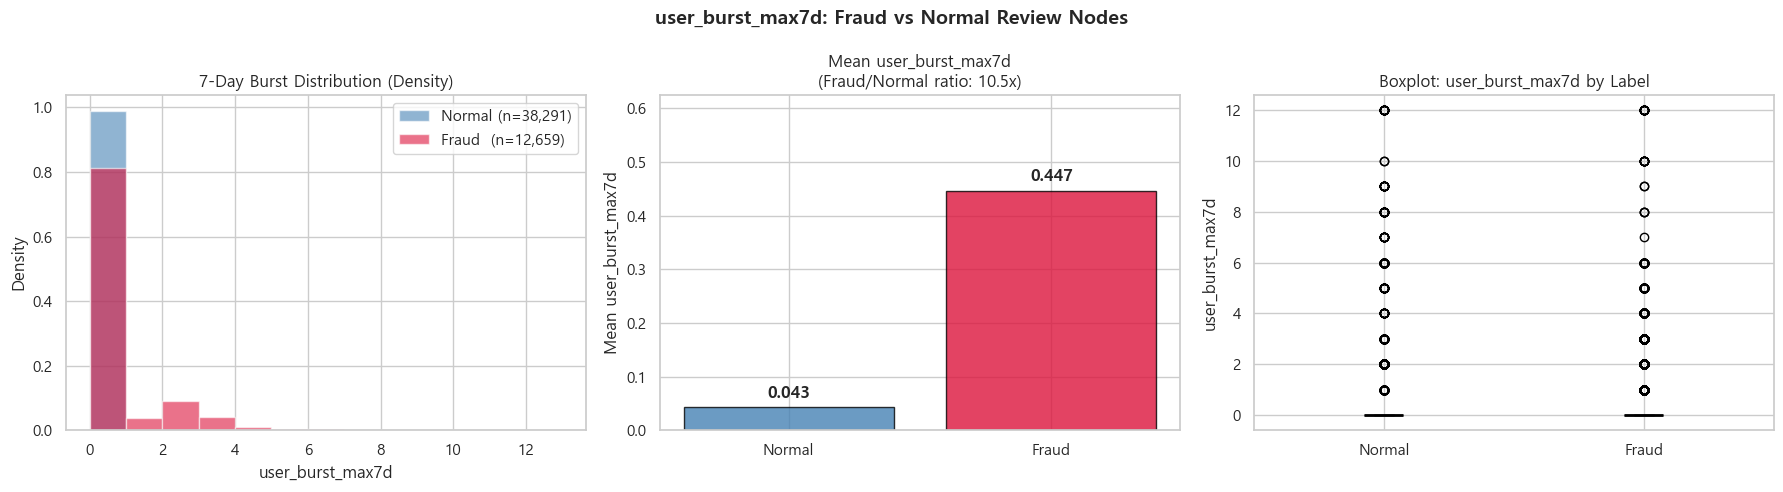

사기 리뷰 노드  — 평균: 0.447, 중앙값: 0.0, 최대: 12
정상 리뷰 노드  — 평균: 0.043, 중앙값: 0.0, 최대: 12
변별력 (Fraud/Normal 평균 비): 10.5배
시각화 저장 완료: burst_max7d_by_label.png


: 

In [ ]:
# user_burst_max7d 라벨별 분포 시각화
fraud_vals  = df_with_burst.loc[df_with_burst["label"] == 1, "user_burst_max7d"]
normal_vals = df_with_burst.loc[df_with_burst["label"] == 0, "user_burst_max7d"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("user_burst_max7d: Fraud vs Normal Review Nodes", fontsize=14, fontweight="bold")

# -- 그래프 1: 히스토그램 비교 (로그 스케일)
ax = axes[0]
max_val = int(df_with_burst["user_burst_max7d"].max()) + 2
bins = range(0, min(max_val, 20))
ax.hist(normal_vals, bins=bins, alpha=0.6, color="steelblue", density=True, label=f"Normal (n={len(normal_vals):,})")
ax.hist(fraud_vals,  bins=bins, alpha=0.6, color="crimson",   density=True, label=f"Fraud  (n={len(fraud_vals):,})")
ax.set_title("7-Day Burst Distribution (Density)")
ax.set_xlabel("user_burst_max7d")
ax.set_ylabel("Density")
ax.legend()

# -- 그래프 2: 평균 비교 막대그래프
ax = axes[1]
means = [normal_vals.mean(), fraud_vals.mean()]
bars = ax.bar(["Normal", "Fraud"], means, color=["steelblue", "crimson"], alpha=0.8, edgecolor="black")
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
ratio = means[1] / means[0] if means[0] > 0 else float("inf")
ax.set_title(f"Mean user_burst_max7d\n(Fraud/Normal ratio: {ratio:.1f}x)")
ax.set_ylabel("Mean user_burst_max7d")
ax.set_ylim(0, max(means) * 1.4)

# -- 그래프 3: 박스플롯 비교
ax = axes[2]
bp = ax.boxplot(
    [normal_vals, fraud_vals],
    labels=["Normal", "Fraud"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("crimson")
bp["boxes"][1].set_alpha(0.7)
ax.set_title("Boxplot: user_burst_max7d by Label")
ax.set_ylabel("user_burst_max7d")

plt.tight_layout()
plt.savefig("burst_max7d_by_label.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"사기 리뷰 노드  — 평균: {fraud_vals.mean():.3f}, 중앙값: {fraud_vals.median():.1f}, 최대: {int(fraud_vals.max())}")
print(f"정상 리뷰 노드  — 평균: {normal_vals.mean():.3f}, 중앙값: {normal_vals.median():.1f}, 최대: {int(normal_vals.max())}")
print(f"변별력 (Fraud/Normal 평균 비): {fraud_vals.mean() / normal_vals.mean():.1f}배")
print("시각화 저장 완료: burst_max7d_by_label.png")


### 2-6. 버스트 분석 종합 시각화

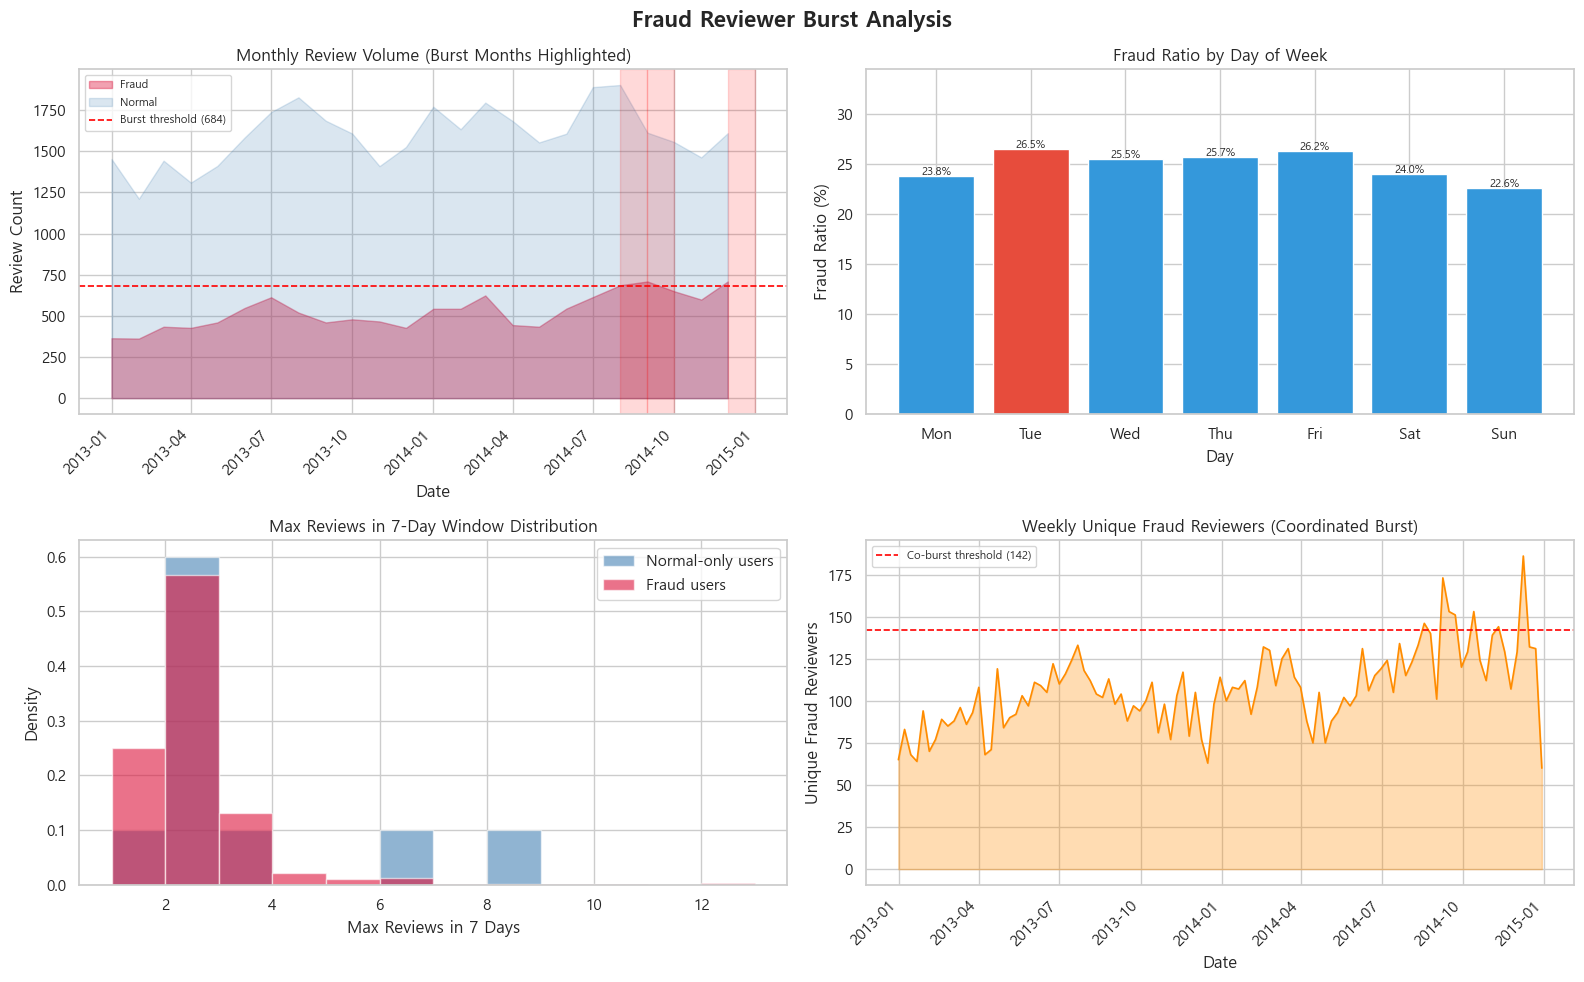

시각화 저장 완료: burst_analysis.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Fraud Reviewer Burst Analysis", fontsize=16, fontweight="bold")

# 그래프 1: 월별 사기 리뷰 추이 + 버스트 구간 강조
ax = axes[0, 0]
ax.fill_between(monthly.index, monthly["fraud"], alpha=0.4, color="crimson", label="Fraud")
ax.fill_between(monthly.index, monthly["normal"], alpha=0.2, color="steelblue", label="Normal")
ax.axhline(burst_thresh, color="red", linestyle="--", linewidth=1.2,
           label=f"Burst threshold ({burst_thresh:.0f})")
for idx in burst_months.index:
    ax.axvspan(idx, idx + pd.DateOffset(months=1), alpha=0.15, color="red")
ax.set_title("Monthly Review Volume (Burst Months Highlighted)")
ax.set_xlabel("Date"); ax.set_ylabel("Review Count")
ax.legend(fontsize=8); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 그래프 2: 요일별 사기 비율
ax = axes[0, 1]
days_kr = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
colors  = ["#e74c3c" if r == wday_ratio.max() else "#3498db" for r in wday_ratio.values]
ax.bar(days_kr, wday_ratio.values * 100, color=colors)
ax.set_title("Fraud Ratio by Day of Week")
ax.set_xlabel("Day"); ax.set_ylabel("Fraud Ratio (%)")
ax.set_ylim(0, wday_ratio.max() * 100 * 1.3)
for i, v in enumerate(wday_ratio.values):
    ax.text(i, v * 100 + 0.1, f"{v*100:.1f}%", ha="center", fontsize=8)

# 그래프 3: 7일 이내 최대 리뷰 수 분포
ax = axes[1, 0]
fraud_burst  = burst_df[burst_df["fraud_reviews"] > 0]["max_in_7days"]
normal_burst = burst_df[burst_df["fraud_reviews"] == 0]["max_in_7days"]
bins = range(1, min(burst_df["max_in_7days"].max() + 2, 30))
ax.hist(normal_burst, bins=bins, alpha=0.6, color="steelblue", label="Normal-only users", density=True)
ax.hist(fraud_burst,  bins=bins, alpha=0.6, color="crimson",   label="Fraud users",      density=True)
ax.set_title("Max Reviews in 7-Day Window Distribution")
ax.set_xlabel("Max Reviews in 7 Days"); ax.set_ylabel("Density")
ax.legend()

# 그래프 4: 주간 협력 버스트
ax = axes[1, 1]
ax.plot(weekly.index, weekly["fraud_users"], color="darkorange", linewidth=1.2)
ax.fill_between(weekly.index, weekly["fraud_users"], alpha=0.3, color="darkorange")
ax.axhline(co_thresh, color="red", linestyle="--", linewidth=1.2,
           label=f"Co-burst threshold ({co_thresh:.0f})")
ax.set_title("Weekly Unique Fraud Reviewers (Coordinated Burst)")
ax.set_xlabel("Date"); ax.set_ylabel("Unique Fraud Reviewers")
ax.legend(fontsize=8); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("burst_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("시각화 저장 완료: burst_analysis.png")